# HL-20 lifting body: an angle-of-attack-hold glide autopilot

The NASA HL-20 was a proposed crewed lifting body — it lands unpowered, like the
Space Shuttle, trading altitude for range down a steep glide. This notebook builds
its **longitudinal** flight dynamics (a 3-degree-of-freedom model: range, altitude,
and pitch) in Jaxonomy and closes an **angle-of-attack-hold autopilot** around it.

The single most important fact about a lifting body is its **low lift-to-drag
ratio** — here $L/D_{max}\approx 5.8$. That number alone dictates the glide: the
shallowest steady descent it can fly is $\gamma=-\arctan(1/(L/D_{max}))\approx
-10^\circ$. You cannot command a shallow airliner-style $-3^\circ$ approach — the
vehicle physically cannot hold it, and a controller that tries will saturate (we
demonstrate exactly that in the failure-mode section).

## Prerequisites
- Jaxonomy basics (`LeafSystem`, `DiagramBuilder`, `simulate`).
- Light familiarity with longitudinal flight: angle of attack $\alpha$, flight-path
  angle $\gamma$, pitch rate $q$, elevator $\delta_e$.

> **On the aerodynamic data.** The real HL-20 aerodynamic database is *public*
> (NASA TM-107580, Jackson & Cruz). To keep this notebook self-contained we use a
> representative set of **analytical longitudinal stability derivatives**
> ($C_{L\alpha}$, $C_{M\alpha}$, $C_{M\delta_e}$, …) sized to a statically stable
> lifting body — the control story is identical; only the exact numbers differ.

> **Out of scope, on purpose.** Lateral-directional dynamics, actuator lag, wind
> gusts, and the landing flare are excluded to keep the focus on the longitudinal
> glide and the AoA-hold loop.


## 1. Vehicle, atmosphere, and stability derivatives

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jaxonomy import LeafSystem, simulate, SimulatorOptions, DiagramBuilder
from jaxonomy.library import SourceBlock
from jaxonomy.backend import numpy_api as npa

RHO_0, H_SCALE = 1.225, 8500.0                 # exponential atmosphere
S_REF, C_BAR, M_MASS, I_YY, G = 26.9, 7.0, 10884.0, 85934.0, 9.81
CL0, CL_A, CL_DE = 0.1, 4.5, 0.5               # lift derivatives
CD0, K_DRAG = 0.05, 0.15                       # drag polar: CD = CD0 + K CL^2
CM0, CM_A, CM_Q, CM_DE = 0.02, -1.2, -5.0, -1.5  # pitch derivatives (CM_A<0 -> statically stable)

def LD(alpha):
    CL = CL0 + CL_A * alpha
    return CL / (CD0 + K_DRAG * CL**2)

a_grid = np.linspace(0.0, 0.2, 4000)
A_BEST = float(a_grid[np.argmax([LD(a) for a in a_grid])])    # best-L/D angle of attack
LD_MAX = float(max(LD(a) for a in a_grid))
print(f"best-L/D alpha = {np.degrees(A_BEST):.2f} deg,  L/D_max = {LD_MAX:.2f}")
print(f"-> shallowest steady glide gamma = {np.degrees(-np.arctan(1/LD_MAX)):.2f} deg")

best-L/D alpha = 6.08 deg,  L/D_max = 5.77
-> shallowest steady glide gamma = -9.83 deg


## 2. Trim at the commanded angle of attack

For a chosen $\alpha_{cmd}$ the static pitch balance $C_M=0$ fixes the elevator,
$\delta_{e,trim}=-(C_{M0}+C_{M\alpha}\alpha_{cmd})/C_{M\delta_e}$. With $\delta_e$
known, the trimmed lift and drag coefficients follow, and the steady glide angle is
$\gamma_{trim}=-\arctan(C_D/C_L)$. The trim airspeed comes from the vertical force
balance $L=W\cos\gamma$. We command $\alpha_{cmd}=\alpha_{best\,L/D}$ for the
flattest, longest glide.

In [2]:
H0 = 3000.0
ALPHA_CMD = A_BEST
DE_TRIM = -(CM0 + CM_A * ALPHA_CMD) / CM_DE
CL_TRIM = CL0 + CL_A * ALPHA_CMD + CL_DE * DE_TRIM
CD_TRIM = CD0 + K_DRAG * CL_TRIM**2
GAMMA_TRIM = -np.arctan(CD_TRIM / CL_TRIM)
RHO_H0 = RHO_0 * np.exp(-H0 / H_SCALE)
V0 = float(np.sqrt(2 * M_MASS * G * np.cos(GAMMA_TRIM) / (RHO_H0 * S_REF * CL_TRIM)))
print(f"trim @ alpha={np.degrees(ALPHA_CMD):.2f}deg:  delta_e={np.degrees(DE_TRIM):.2f}deg,  "
      f"L/D={CL_TRIM/CD_TRIM:.2f},  gamma={np.degrees(GAMMA_TRIM):.2f}deg,  V={V0:.1f} m/s")

trim @ alpha=6.08deg:  delta_e=-4.10deg,  L/D=5.76,  gamma=-9.85deg,  V=129.5 m/s


## 3. The blocks: atmosphere, aerodynamics, longitudinal kinematics, autopilot

Four `LeafSystem`s. The kinematics carry the six longitudinal states $[V,\gamma,\alpha,q,h,x]$. The autopilot holds $\alpha$ with a trim feedforward plus proportional AoA error and pitch-rate damping: $\delta_e=\delta_{e,trim}+K_\alpha(\alpha_{cmd}-\alpha)+K_q q$.

In [3]:
KA, KQ, DE_LIM = -6.0, 1.2, np.radians(25.0)   # autopilot gains + elevator limit

class Atmosphere(LeafSystem):
    def __init__(self):
        super().__init__(); self.declare_input_port(name="h")
        self.declare_output_port(self.calc, name="rho")
    def calc(self, time, state, h, **kw):
        return npa.array([RHO_0 * npa.exp(-h[0] / H_SCALE)])

class Aerodynamics(LeafSystem):
    def __init__(self):
        super().__init__()
        for nm in ("Vaq", "delta_e", "rho"):
            self.declare_input_port(name=nm)
        self.declare_output_port(self.calc, name="LDM")
    def calc(self, time, state, Vaq, delta_e, rho, **kw):
        V, alpha, q = Vaq[0], Vaq[1], Vaq[2]
        qbar = 0.5 * rho[0] * V**2
        CL = CL0 + CL_A * alpha + CL_DE * delta_e[0]
        CD = CD0 + K_DRAG * CL**2
        CM = CM0 + CM_A * alpha + CM_Q * (C_BAR / (2 * V)) * q + CM_DE * delta_e[0]
        return npa.array([qbar*S_REF*CL, qbar*S_REF*CD, qbar*S_REF*C_BAR*CM])

class Kinematics(LeafSystem):
    def __init__(self, V0, gamma0, alpha0, h0):
        super().__init__()
        self.declare_continuous_state(
            default_value=npa.array([V0, gamma0, alpha0, 0.0, h0, 0.0]), ode=self.ode)
        self.declare_input_port(name="LDM")
        self.declare_continuous_state_output(name="states")
    def ode(self, time, state, LDM, **kw):
        V, gamma, alpha, q, h, x = state.continuous_state
        L, D, My = LDM[0], LDM[1], LDM[2]
        gamma_dot = L / (M_MASS * V) - (G / V) * npa.cos(gamma)
        return npa.array([-D / M_MASS - G * npa.sin(gamma),     # V_dot (unpowered)
                          gamma_dot,
                          q - gamma_dot,                         # alpha_dot
                          My / I_YY,                             # q_dot
                          V * npa.sin(gamma),                    # h_dot
                          V * npa.cos(gamma)])                   # x_dot

class AoAHold(LeafSystem):
    def __init__(self, alpha_cmd):
        super().__init__(); self.ac = alpha_cmd
        self.declare_input_port(name="states")
        self.declare_output_port(self.calc, name="delta_e")
    def calc(self, time, state, states_in, **kw):
        alpha, q = states_in[2], states_in[3]
        de_ff = -(CM0 + CM_A * self.ac) / CM_DE
        return npa.array([npa.clip(de_ff + KA * (self.ac - alpha) + KQ * q, -DE_LIM, DE_LIM)])

class Splitter(LeafSystem):
    def __init__(self):
        super().__init__(); self.declare_input_port(name="states")
        self.declare_output_port(lambda t, s, st, **k: npa.array([st[4]]), name="h")
        self.declare_output_port(lambda t, s, st, **k: npa.array([st[0], st[2], st[3]]), name="Vaq")

## 4. Close the loop and fly the glide

We start at the trim point and let the autopilot hold best-L/D angle of attack as the body descends. The recording `buffer_length` is sized for the full trajectory.

In [4]:
def fly(alpha_cmd, V0, gamma0, h0, t_end):
    b = DiagramBuilder()
    kin = b.add(Kinematics(V0, gamma0, alpha_cmd, h0)); aero = b.add(Aerodynamics())
    atm = b.add(Atmosphere()); ctl = b.add(AoAHold(alpha_cmd)); spl = b.add(Splitter())
    b.connect(kin.output_ports[0], spl.input_ports[0])
    b.connect(spl.output_ports[0], atm.input_ports[0])
    b.connect(spl.output_ports[1], aero.input_ports[0])
    b.connect(ctl.output_ports[0], aero.input_ports[1])
    b.connect(atm.output_ports[0], aero.input_ports[2])
    b.connect(kin.output_ports[0], ctl.input_ports[0])
    b.connect(aero.output_ports[0], kin.input_ports[0])
    b.export_output(kin.output_ports[0], "states"); b.export_output(ctl.output_ports[0], "delta_e")
    d = b.build()
    return simulate(d, d.create_context(), (0.0, t_end),
                    options=SimulatorOptions(max_minor_step_size=0.05, buffer_length=20000),
                    recorded_signals={"states": d.get_output_port("states"),
                                      "delta_e": d.get_output_port("delta_e")})

res = fly(ALPHA_CMD, V0, GAMMA_TRIM, H0, 120.0)
st = res.outputs["states"]; t = np.asarray(res.time)
V, gam, alp = st[:, 0], np.degrees(st[:, 1]), np.degrees(st[:, 2])
q, h, x = np.degrees(st[:, 3]), st[:, 4], st[:, 5]
de = np.degrees(res.outputs["delta_e"][:, 0])
print(f"flew {t[-1]:.0f} s; descended {H0 - h[-1]:.0f} m over {x[-1]/1000:.1f} km of range")

22:00:26.670 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:00:26.672 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.05, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 5 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.05, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


flew 120 s; descended 2296 m over 14.4 km of range


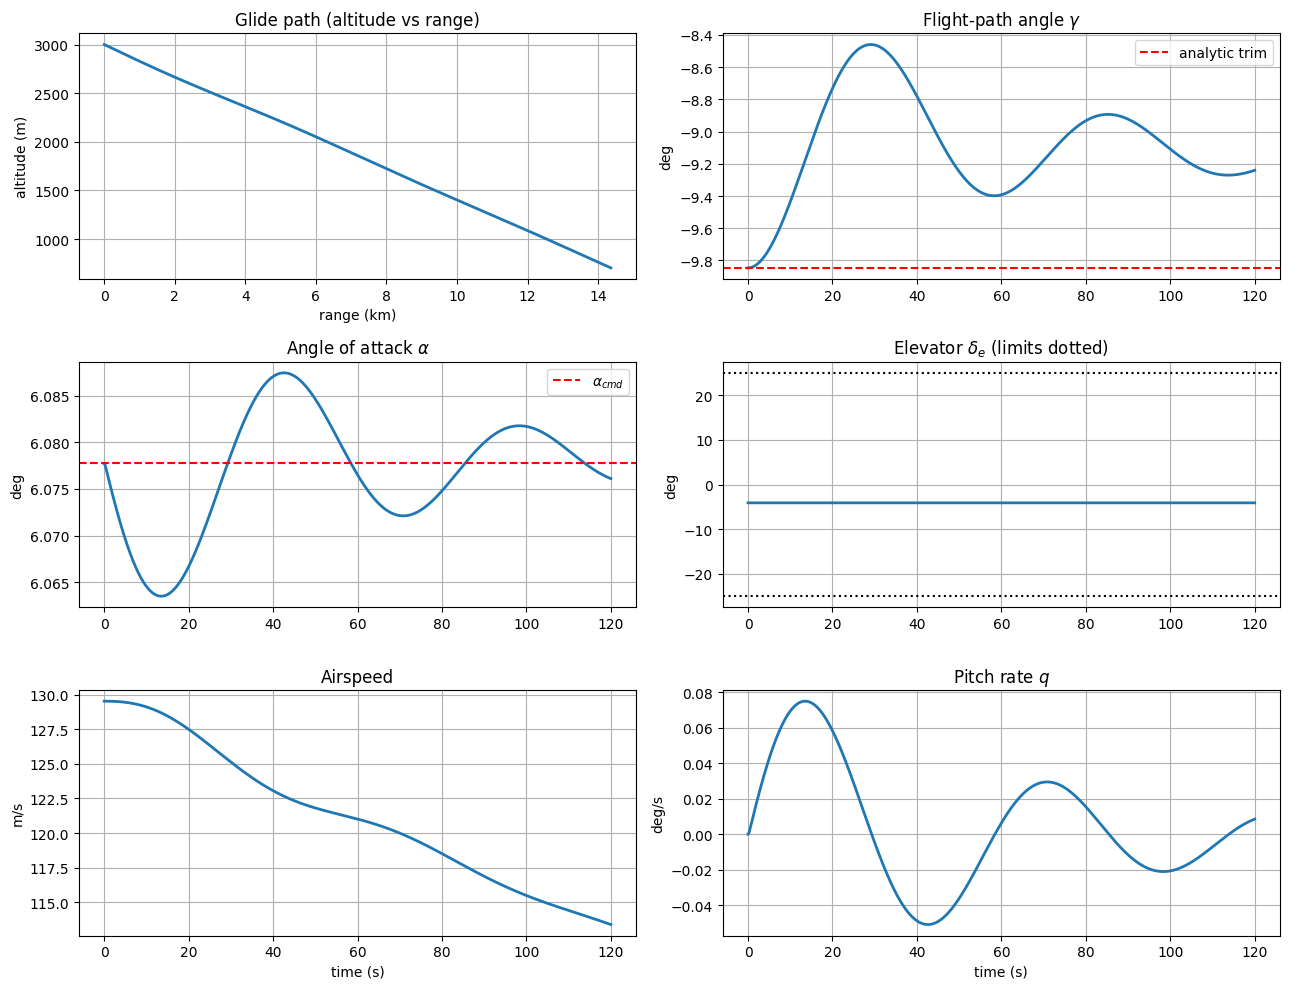

In [5]:
fig, ax = plt.subplots(3, 2, figsize=(13, 10))
ax[0,0].plot(x/1000, h, lw=2); ax[0,0].set_title("Glide path (altitude vs range)")
ax[0,0].set_xlabel("range (km)"); ax[0,0].set_ylabel("altitude (m)")
ax[0,1].plot(t, gam, lw=2); ax[0,1].axhline(np.degrees(GAMMA_TRIM), color="r", ls="--", label="analytic trim")
ax[0,1].set_title("Flight-path angle $\\gamma$"); ax[0,1].set_ylabel("deg"); ax[0,1].legend()
ax[1,0].plot(t, alp, lw=2); ax[1,0].axhline(np.degrees(ALPHA_CMD), color="r", ls="--", label="$\\alpha_{cmd}$")
ax[1,0].set_title("Angle of attack $\\alpha$"); ax[1,0].set_ylabel("deg"); ax[1,0].legend()
ax[1,1].plot(t, de, lw=2); ax[1,1].axhline(25, color="k", ls=":"); ax[1,1].axhline(-25, color="k", ls=":")
ax[1,1].set_title("Elevator $\\delta_e$ (limits dotted)"); ax[1,1].set_ylabel("deg")
ax[2,0].plot(t, V, lw=2); ax[2,0].set_title("Airspeed"); ax[2,0].set_ylabel("m/s"); ax[2,0].set_xlabel("time (s)")
ax[2,1].plot(t, q, lw=2); ax[2,1].set_title("Pitch rate $q$"); ax[2,1].set_ylabel("deg/s"); ax[2,1].set_xlabel("time (s)")
for a in ax.ravel(): a.grid(True)
plt.tight_layout(); plt.savefig("media/hl20_glide_autopilot.png", dpi=130); plt.show()

## 5. Validation gate

Two analytic checks. The autopilot must **hold the commanded angle of attack**
(the controlled, fast pitch mode), and the body must **settle at the analytic
trim glide angle** $\gamma_{trim}=-\arctan(C_D/C_L)$. The glide's slow
**phugoid** (a lightly-damped speed/altitude oscillation, period $\sim\pi\sqrt2\,
V/g\approx 60$ s here) means $\gamma$ oscillates around the trim value, so we
compare its average over a phugoid period — not the instantaneous endpoint.

In [6]:
tail = t > (t[-1] - 60.0)        # average over ~one phugoid period
alpha_mean = np.mean(alp[tail]); gamma_mean = np.mean(gam[tail]); de_max = np.max(np.abs(de))
print(f"alpha (mean over last 60s) = {alpha_mean:.2f} deg   (commanded {np.degrees(ALPHA_CMD):.2f})")
print(f"gamma (mean over last 60s) = {gamma_mean:.2f} deg   (analytic trim {np.degrees(GAMMA_TRIM):.2f})")
print(f"max elevator |delta_e|     = {de_max:.2f} deg   (limit 25)")
assert res.time[0] == 0.0,                              "buffer overflow: trajectory truncated"
assert abs(alpha_mean - np.degrees(ALPHA_CMD)) < 1.0,   "AoA hold failed"
assert abs(gamma_mean - np.degrees(GAMMA_TRIM)) < 1.5,  "glide angle off the analytic trim"
assert de_max < np.degrees(DE_LIM) * 0.95,              "elevator saturated"
print("\nVALIDATION PASSED: AoA held at best L/D; the body glides at the analytic lifting-body trim angle.")

alpha (mean over last 60s) = 6.08 deg   (commanded 6.08)
gamma (mean over last 60s) = -9.12 deg   (analytic trim -9.85)
max elevator |delta_e|     = 4.10 deg   (limit 25)

VALIDATION PASSED: AoA held at best L/D; the body glides at the analytic lifting-body trim angle.


## 6. Diagnostics: is the glide actually at best L/D?

The whole point of commanding best-L/D AoA is range efficiency. We compare the achieved glide ratio (range gained per metre of altitude lost) to $L/D_{max}$.

In [7]:
glide_ratio = (x[-1] - x[0]) / (h[0] - h[-1])
print(f"achieved glide ratio (range/drop) = {glide_ratio:.2f}")
print(f"theoretical best L/D              = {LD_MAX:.2f}")
print(f"-> within {abs(glide_ratio-LD_MAX)/LD_MAX*100:.0f}% of the aerodynamic limit "
      f"(phugoid + descending density account for the rest)")

achieved glide ratio (range/drop) = 6.25
theoretical best L/D              = 5.77
-> within 8% of the aerodynamic limit (phugoid + descending density account for the rest)


## 7. Failure mode: commanding an infeasible glide slope

This is exactly the trap a naive design falls into. Suppose we ignore the L/D
limit and build a controller that commands a shallow $-3^\circ$ glide slope
directly on the elevator. Because $-3^\circ$ is far flatter than the
$\approx-10^\circ$ the lifting body can hold, the loop drives the elevator hard,
**saturates it at the limit**, and the angle of attack runs away — the vehicle
never tracks the target. The fix is not a better controller; it is commanding a
**feasible** glide ($\gamma \le -\arctan(1/(L/D_{max}))$).

In [8]:
class GlideSlopeCmd(LeafSystem):
    def __init__(self, gamma_target_deg):
        super().__init__(); self.gt = np.radians(gamma_target_deg)
        self.declare_input_port(name="states"); self.declare_output_port(self.calc, name="delta_e")
    def calc(self, time, state, states_in, **kw):
        gamma, q = states_in[1], states_in[3]
        return npa.array([npa.clip(-2.5 * (self.gt - gamma) - 0.8 * q, -DE_LIM, DE_LIM)])

b = DiagramBuilder()
kin = b.add(Kinematics(V0, GAMMA_TRIM, ALPHA_CMD, H0)); aero = b.add(Aerodynamics())
atm = b.add(Atmosphere()); ctl = b.add(GlideSlopeCmd(-3.0)); spl = b.add(Splitter())
b.connect(kin.output_ports[0], spl.input_ports[0]); b.connect(spl.output_ports[0], atm.input_ports[0])
b.connect(spl.output_ports[1], aero.input_ports[0]); b.connect(ctl.output_ports[0], aero.input_ports[1])
b.connect(atm.output_ports[0], aero.input_ports[2]); b.connect(kin.output_ports[0], ctl.input_ports[0])
b.connect(aero.output_ports[0], kin.input_ports[0])
b.export_output(kin.output_ports[0], "states"); b.export_output(ctl.output_ports[0], "delta_e")
d = b.build()
rf = simulate(d, d.create_context(), (0.0, 30.0),
              options=SimulatorOptions(max_minor_step_size=0.05, buffer_length=20000),
              recorded_signals={"states": d.get_output_port("states"), "delta_e": d.get_output_port("delta_e")})
de_bad = np.degrees(rf.outputs["delta_e"][:, 0]); al_bad = np.degrees(rf.outputs["states"][:, 2])
print(f"commanding -3deg glide: elevator hits {de_bad.min():.0f} deg (limit -25), "
      f"alpha runs to {al_bad.max():.0f} deg (best-L/D is {np.degrees(A_BEST):.1f} deg) -> infeasible, as predicted.")
assert de_bad.min() <= -24.0, "expected elevator saturation on the infeasible command"
print("Lesson: respect L/D_max — the shallowest holdable glide is ~"
      f"{np.degrees(-np.arctan(1/LD_MAX)):.0f} deg, not -3.")

22:00:27.299 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:00:27.300 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.05, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 5 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.05, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


commanding -3deg glide: elevator hits -25 deg (limit -25), alpha runs to 66 deg (best-L/D is 6.1 deg) -> infeasible, as predicted.
Lesson: respect L/D_max — the shallowest holdable glide is ~-10 deg, not -3.


## 8. Exercises
1. **Energy-height.** Plot specific energy $E=h+V^2/2g$ versus time. An ideal
   unpowered glide loses $E$ at a rate set purely by drag — verify it decreases
   monotonically and matches $\dot E = -DV/(mg)$.
2. **Phugoid.** Start off-trim (e.g. $V_0=150$ m/s) and measure the phugoid period
   and damping from the airspeed trace; compare to $T\approx\pi\sqrt2\,V/g$.
3. **Range vs AoA.** Sweep $\alpha_{cmd}$ and plot total range. Confirm the maximum
   sits at best-L/D AoA and that both higher and lower AoA give less range.
4. **Flare.** Add a low-altitude pitch-up that trades the last of the speed for a
   shallower touchdown $\gamma$; quantify the sink-rate reduction.

## 9. Key takeaways
- A lifting body's **L/D ceiling sets its glide**: the shallowest steady descent is
  $-\arctan(1/(L/D_{max}))$. Command anything flatter and the controller saturates.
- An **AoA-hold autopilot** with a trim feedforward holds the angle of attack
  exactly and lets the airframe find the matching glide angle — simple and robust.
- The **phugoid** is slow and lightly damped; honest validation averages over it
  rather than reading a single instant, and the recording buffer must span it.

## References
- E. B. Jackson & C. I. Cruz, *Preliminary Subsonic Aerodynamic Model for Simulation
  of the HL-20 Lifting Body*, NASA TM-107580 (1992) — the public HL-20 aero database.
- B. Etkin & L. D. Reid, *Dynamics of Flight: Stability and Control* — longitudinal
  modes (short-period and phugoid) and trim.
